# <span style="color:orange">Quality Data Analysis - Project Work [FULL PROJECT] </span>
## Team [TEAM NUMBER HERE]

### Course Details:
- Academic Year: 2025-2026

### Project Details:
- Title: [ENTER PROJECT TITLE HERE]

### Team Members:
- [ENTER NAME 1 HERE]
- [ENTER NAME 2 HERE]
- [ENTER NAME 3 HERE]
- [ENTER NAME 4 HERE]

### Instructor:
- [ENTER INSTRUCTOR NAME HERE]

# Instructions
- This is a template notebook for the project work.
- Please fill in the details above (team members, instructor, etc.)
## PHASE 1 - Report structure
Please use the following sections for your project report:
- **Introduction** [max 3500 characters including spaces]
    - Recap the project work framework and objective
    - Briefly summarize the overall methodology you used to model and analyse your data
    - Briefly summarize the state-of-the-art you analysed to support your study (if any).
- **Assumptions and preliminary data analysis** [max 5000 characters including spaces]
    - Clearly state and motivate all the assumptions your proposed methodology relies on; present and discuss any preliminary data analysis and visualization you applied on the data.
- **Proposed methodology** [max 10000 characters including spaces]
    - Synthetically describe, motivate and critically discuss your proposed statistical process monitoring approach. 
- **Results** [max 10000 characters including spaces]
    - Synthetically presents and discuss the results of your statistical process monitoring design. 

## PHASE 2 - Report structure
Please use the following sections for your project report:
- **Preliminary data analysis** [max 5000 characters including spaces]
    - Synthetically describe and discuss any preliminary data analysis and visualization applied on the new dataset.
- **Test of your proposed approach on new data** [max 5000 characters including spaces]
    - Synthetically presents and discuss the results you got applying to the new data your previously designed statistical process monitoring approach.
- **Discussion** [max 5000 characters including spaces]
    - Critically discuss your results In this Section you can also propose possible ways to tune or revise your previously designed method to enhance its defect detection performance. 

You can add code cells to any of the above sections to show your code or display images. Each block of code should be accompanied by a brief description of what it does (not counted in characters limits).

## Submission
- Name your notebook as `teamXX.ipynb` where `XX` is your team number.
- Submit your notebook together with the Dataframe as a ZIP file on Webeep by the deadline. The ZIP file name must clearly state the "TEAM NUMBER".

# PHASE 1 ------------------------------

# Introduction


- Kurzer Kontext: Automatisierte Qualitätskontrolle für additive Fertigung (LFAM) im Weltraum-Kontext.
- Ziel des Projekts: Design eines vollautomatisierten SPC-Systems (Statistical Process Control), das anhand von Bilddaten Anomalien im Druckprozess erkennt.
- Gewählte Methode: Principal Component Analysis (PCA) zur Reduktion der Dimensionen der Bilddaten

# Assumptions and preliminary data analysis

- Die traditionelle SPC fordert unabhängige Daten. Da bei der Bildaufnahme explizit darauf geachtet wurde, Überschneidungen zu vermeiden (Gapping), nimmst du an, dass die 132 Bilder unabhängig voneinander sind. Diese Annahme rechtfertigt es erst, dass du später die klassischen Kontrollgrenzen berechnen darfst.
- Datenvorbereitung: Die Bilder (Matrizen der Größe 115x180) müssen als 1D-Vektoren "ausgerollt" werden, um die PCA anwenden zu können.
- Explorative Analyse: Einige der Trainingsbilder plotten. Histogramme der Pixelintensitäten zeigen, um das Rauschen und das Prozessleuchten zu verstehen.
- Data Centering: Das Durchschnittsbild (Mean Image) aller 132 Bilder berechnen und von jedem einzelnen Bild abziehen. Das ist für die PCA zwingend notwendig

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Pfad zum Datensatz
dataset_path = 'Phase1 dataset'

# Liste der Bilddateien laden und numerisch sortieren (image_1, image_2, ...)
filenames = sorted([f for f in os.listdir(dataset_path) if f.endswith('.png')],
                   key=lambda x: int(x.split('_')[1].split('.')[0]))

# Bilder einlesen
images_list = []
for f in filenames:
    img = plt.imread(os.path.join(dataset_path, f))
    # Da plt.imread float32 (0-1) zurückgibt, skalieren wir auf 0-255 für die Konsistenz
    images_list.append(img * 255)

images = np.array(images_list)
print(images.shape) 

(132, 115, 180)


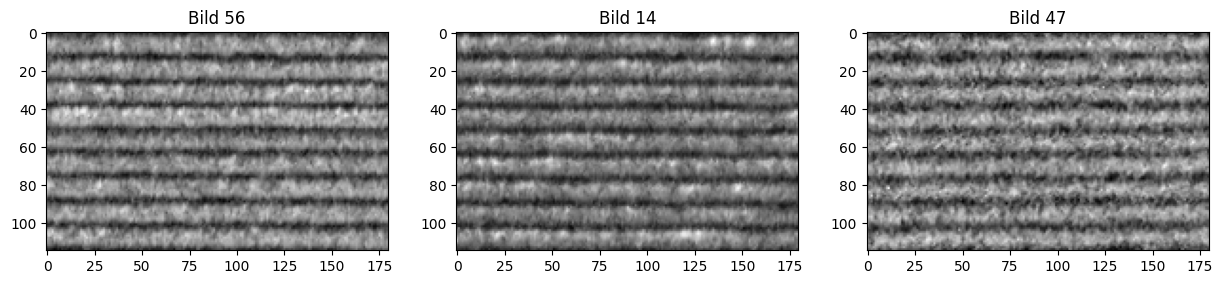

In [94]:
# Lass dir ein paar zufällige Bilder anzeigen, um Prozessleuchten und Hintergrund zu sichten
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    random_idx = np.random.randint(0, 132) # Zufälligen Index wählen
    # cmap='gray' sorgt für die Graustufendarstellung (0=schwarz, 255=weiß)
    ax[i].imshow(images[random_idx], cmap='gray', vmin=0, vmax=255)
    ax[i].set_title(f'Bild {random_idx}')
plt.show()

Dimensionen der Datenmatrix X: (132, 20700)
Mittelwert der zentrierten Datenmatrix (sollte nahe 0 sein): -4.3031082e-07


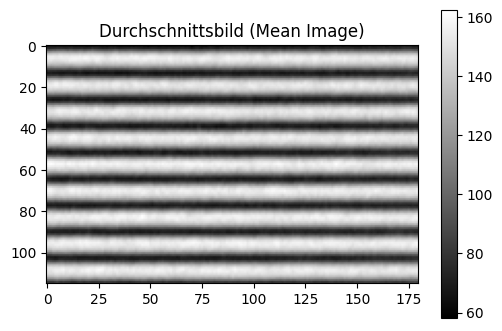

In [95]:
# %% [markdown]
# 2. Bilder umformen ("Flattening") & 3. Die Datenmatrix X erstellen

### %%
# Definition der Dimensionen
n_samples = 132             # Anzahl der Beobachtungen (Bilder)
height, width = 115, 180    # Höhe und Breite jedes Bildes
n_features = height * width # 20.700 Variablen/Pixel

# Jedes 115x180 Bild "ausrollen" (Flattening)
# Die reshape-Funktion wandelt das 3D-Array (132, 115, 180) 
# direkt in eine 2D-Datenmatrix X der Form (132, 20700) um.
X = images.reshape(n_samples, n_features)

print("Dimensionen der Datenmatrix X:", X.shape)
# Erwarteter Output: (132, 20700)

# %% [markdown]
# 4. Wichtige Annahme notieren ("Fewer observations than unknowns")

### %%
# HINWEIS FÜR DEN REPORT:
# In diesem Datensatz haben wir n = 132 Beobachtungen und p = 20.700 Variablen.
# Es gilt also n < p (deutlich weniger Beobachtungen als Unbekannte/Pixel).
#
# Die PCA ist hier dennoch anwendbar. Allerdings ist der Rang der berechneten 
# Kovarianzmatrix maximal n-1 bzw. an die Anzahl der Beobachtungen gebunden. 
# Das bedeutet, dass die PCA in diesem Fall maximal 132 aussagekräftige 
# Hauptkomponenten (Principal Components) extrahieren kann, von denen die 
# restlichen Eigenwerte exakt null sein werden.

# %% [markdown]
# 5. Daten zentrieren (Data Centering - ZWINGEND für PCA)

### %%
# Das "Durchschnittsbild" berechnen.
# Wir berechnen den Mittelwert jeder der 20.700 Spalten über alle 132 Bilder hinweg (axis=0).
mean_image = np.mean(X, axis=0)

# Mittelwert von der Datenmatrix abziehen (Broadcasting zieht den Vektor von jeder Zeile ab)
X_centered = X - mean_image

# Überprüfen, ob die Daten nun um den Nullpunkt zentriert sind
print("Mittelwert der zentrierten Datenmatrix (sollte nahe 0 sein):", np.mean(X_centered))

# (Optional) Lass dir das berechnete Durchschnittsbild anzeigen, um zu sehen, 
# wo im Durchschnitt das Prozessleuchten am stärksten ist:
plt.figure(figsize=(6, 4))
plt.imshow(mean_image.reshape(height, width), cmap='gray')
plt.title('Durchschnittsbild (Mean Image)')
plt.colorbar()
plt.show()

# Ab hier ist X_centered bereit für die PCA (z.B. mit sklearn.decomposition.PCA)


# Proposed methodology

- PCA-Theorie: Kurz erklären, dass die PCA hochdimensionale, korrelierte Daten in unkorrelierte Hauptkomponenten (Principal Components) transformiert, um die Varianz zu maximieren.
- Modellierung: Berechnung der Sample-Kovarianzmatrix S sowie deren Eigenwerte und Eigenvektoren.
- Komponentenauswahl: Erklären, wie viele Hauptkomponenten (K) behalten werden (z.B. durch Festlegen einer erklärten kumulativen Mindestvarianz von z.B. 90% oder 95% oder mittels Scree-Plot).
- Control Charts definieren: Zwei Charts sind für die PCA nötig:

    - Hotelling's T2 Control Chart: Überwacht die extrahierten Scores innerhalb des PCA-Modells. Du musst die statistischen Formeln für das Phase-1-Kontrolllimit (UCL) angeben (basierend auf der Beta-Verteilung).
    - SPE (Squared Prediction Error) Chart / Q-Chart: Überwacht die Residuen, also alles, was das PCA-Modell nicht abbilden konnte (das Rauschen). Formeln für das UCL angeben

Erste 5 Eigenwerte (Explained Variance): 
 [3805433.5   776106.56  601016.94  325011.9   283017.44]

Erste 5 erklärte Varianzverhältnisse (Explained variance ratio): 
 [0.25257966 0.05151285 0.03989156 0.02157215 0.01878484]
Anzahl der Komponenten für 80% Varianz: 72
Anzahl der Komponenten für 90% Varianz: 98


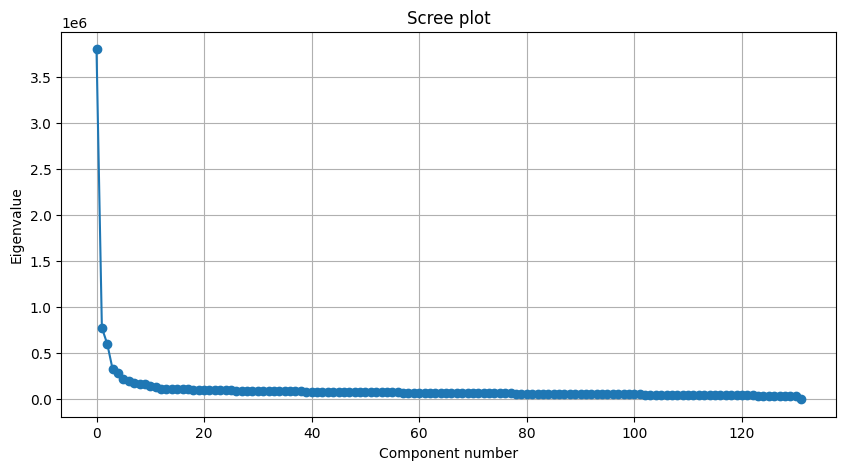

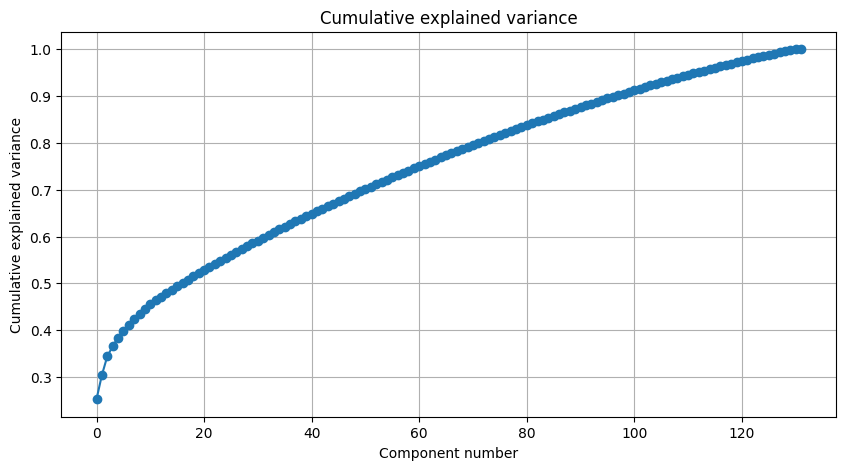

In [96]:
### %%
# PCA-Bibliothek aus scikit-learn importieren [1]
from sklearn.decomposition import PCA

# PCA-Objekt erstellen [1]
pca = PCA()

# PCA auf die zentrierten Daten anwenden (fitten) [1]
pca.fit(X_centered)

# Eigenwerte (erklärte Varianz) und erklärte Varianzverhältnisse ausgeben [1]
# (Da es bis zu 132 Komponenten gibt, lassen wir uns zur Übersicht nur die ersten 5 anzeigen)
print("Erste 5 Eigenwerte (Explained Variance): \n", pca.explained_variance_[:5])
print("\nErste 5 erklärte Varianzverhältnisse (Explained variance ratio): \n", pca.explained_variance_ratio_[:5])

# Kumulierte erklärte Varianz berechnen [1]
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

k_80 = np.argmax(cumulative_variance >= 0.80) + 1
k_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Anzahl der Komponenten für 80% Varianz: {k_80}")
print(f"Anzahl der Komponenten für 90% Varianz: {k_90}")

# Scree-Plot zeichnen, um die Eigenwerte zu vergleichen [2]
plt.figure(figsize=(10, 5))
plt.plot(pca.explained_variance_, 'o-')
plt.xlabel('Component number')
plt.ylabel('Eigenvalue')
plt.title('Scree plot')
plt.grid(True)
plt.show()

# Kumulierte erklärte Varianz plotten [3]
plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, 'o-')
plt.xlabel('Component number')
plt.ylabel('Cumulative explained variance')
plt.title('Cumulative explained variance')
plt.grid(True)
plt.show()

das ist zu ungenau, deswegen wollen wir etwas preprocessing machen um die diemensionen zu verringern vor der PCA

(132, 115)
Mittelwert der zentrierten Datenmatrix (sollte nahe 0 sein): -6.433218e-07


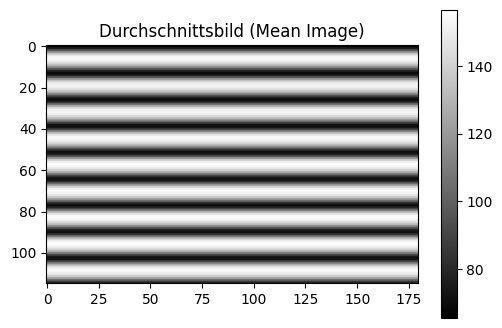

In [97]:
x_reduced = images.mean(axis=2)
print(x_reduced.shape)

### %%
# Das "Durchschnittsbild" berechnen.
# Wir berechnen den Mittelwert jeder der 20.700 Spalten über alle 132 Bilder hinweg (axis=0).
mean_image = np.mean(x_reduced, axis=0)

# Mittelwert von der Datenmatrix abziehen (Broadcasting zieht den Vektor von jeder Zeile ab)
x_centered = x_reduced - mean_image

# Überprüfen, ob die Daten nun um den Nullpunkt zentriert sind
print("Mittelwert der zentrierten Datenmatrix (sollte nahe 0 sein):", np.mean(x_centered))

mean_image_2d = np.repeat(mean_image.reshape(115, 1), 180, axis=1)

plt.figure(figsize=(6, 4))
plt.imshow(mean_image_2d, cmap='gray')
plt.title('Durchschnittsbild (Mean Image)')
plt.colorbar()
plt.show()


Erste 5 Eigenwerte (Explained Variance): 
 [20500.852   3791.8184  2970.79    1171.1536   921.5706]

Erste 5 erklärte Varianzverhältnisse (Explained variance ratio): 
 [0.6051902  0.11193541 0.08769846 0.03457274 0.02720499]
Anzahl der Komponenten für 80% Varianz: 3
Anzahl der Komponenten für 90% Varianz: 7


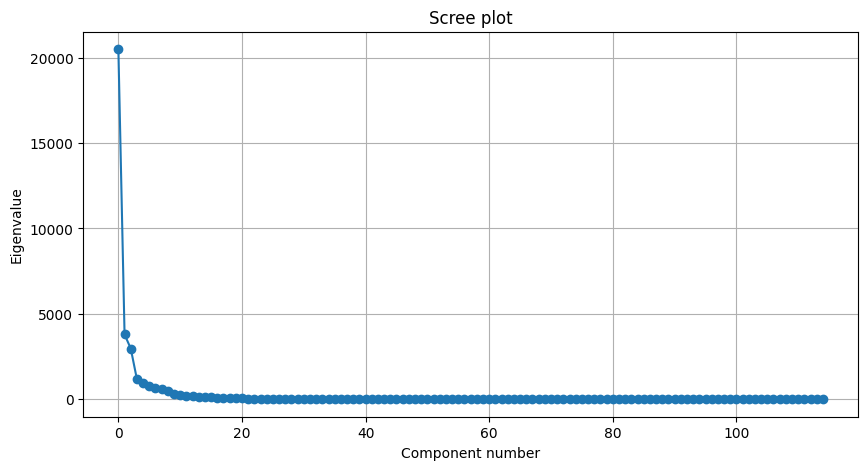

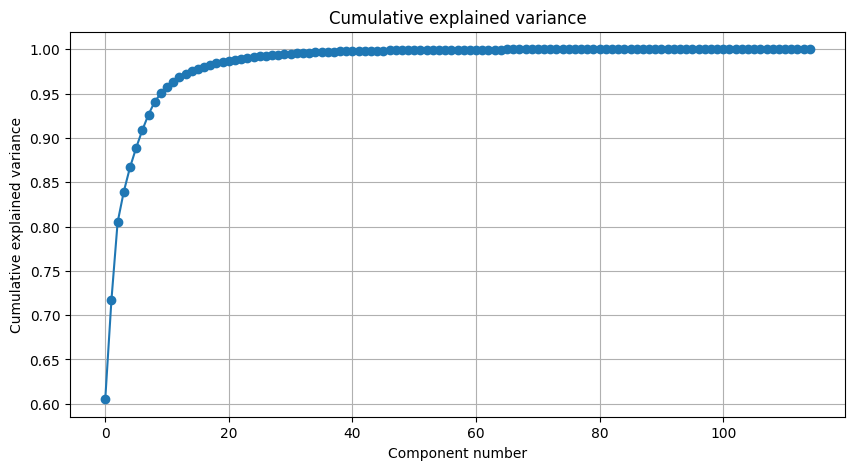

In [98]:
### %%
# PCA-Bibliothek aus scikit-learn importieren [1]
from sklearn.decomposition import PCA

# PCA-Objekt erstellen [1]
pca = PCA()

# PCA auf die zentrierten Daten anwenden (fitten) [1]
pca.fit(x_centered)

# Eigenwerte (erklärte Varianz) und erklärte Varianzverhältnisse ausgeben [1]
# (Da es bis zu 132 Komponenten gibt, lassen wir uns zur Übersicht nur die ersten 5 anzeigen)
print("Erste 5 Eigenwerte (Explained Variance): \n", pca.explained_variance_[:5])
print("\nErste 5 erklärte Varianzverhältnisse (Explained variance ratio): \n", pca.explained_variance_ratio_[:5])

# Kumulierte erklärte Varianz berechnen [1]
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

k_80 = np.argmax(cumulative_variance >= 0.80) + 1
k_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Anzahl der Komponenten für 80% Varianz: {k_80}")
print(f"Anzahl der Komponenten für 90% Varianz: {k_90}")

# Scree-Plot zeichnen, um die Eigenwerte zu vergleichen [2]
plt.figure(figsize=(10, 5))
plt.plot(pca.explained_variance_, 'o-')
plt.xlabel('Component number')
plt.ylabel('Eigenvalue')
plt.title('Scree plot')
plt.grid(True)
plt.show()

# Kumulierte erklärte Varianz plotten [3]
plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, 'o-')
plt.xlabel('Component number')
plt.ylabel('Cumulative explained variance')
plt.title('Cumulative explained variance')
plt.grid(True)
plt.show()

- Obwohl oft 90% erklärte Varianz angestrebt werden, haben wir uns basierend auf dem Scree-Plot (Elbow-Kriterium) für K=4 (~83%) Hauptkomponenten entschieden.
- Eine geringere Dimensionszahl (K=4 statt z.B. K=7 oder mehr) erhöht die statistische Power (Sensitivität) des Hotelling's T2-Charts zur Fehlererkennung, während die verbleibende Varianz durch das SPE-Chart überwacht wird.

jetzt müssen wir die unabhängigkeit überprüfen


ANALYSE FÜR HAUPTKOMPONENTE: z1

--- Runs Test für z1 ---
Runs test statistic = -0.080
Runs test p-value = 0.936



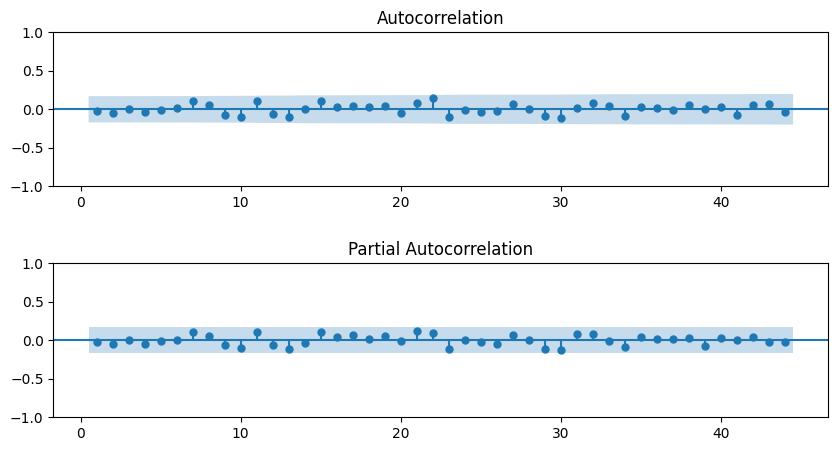


--- Bartlett's Test (Lag = 1) für z1 ---
Bartlett test statistic = -0.097
Bartlett test p-value = 0.267

--- Ljung-Box Q-Test (Lag = 11) für z1 ---
LBQ test statistic = 6.551
LBQ test p-value = 0.834

ANALYSE FÜR HAUPTKOMPONENTE: z2

--- Runs Test für z2 ---
Runs test statistic = -0.164
Runs test p-value = 0.869



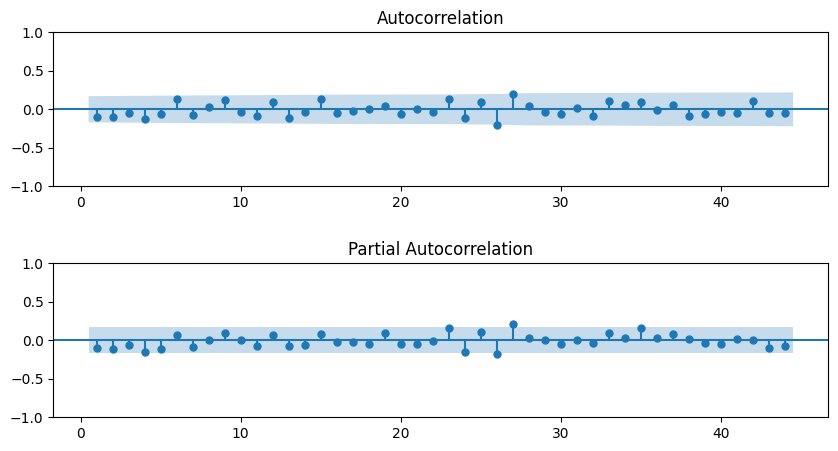


--- Bartlett's Test (Lag = 1) für z2 ---
Bartlett test statistic = -0.036
Bartlett test p-value = 0.678

--- Ljung-Box Q-Test (Lag = 11) für z2 ---
LBQ test statistic = 12.249
LBQ test p-value = 0.345

ANALYSE FÜR HAUPTKOMPONENTE: z3

--- Runs Test für z3 ---
Runs test statistic = 0.881
Runs test p-value = 0.378



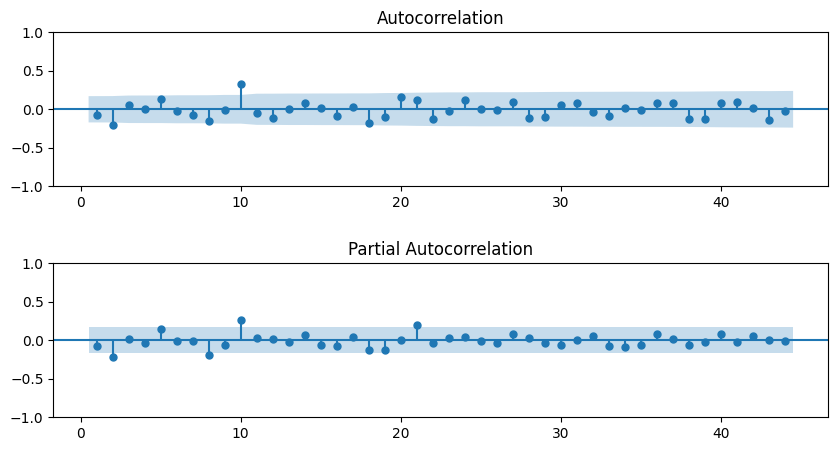


--- Bartlett's Test (Lag = 1) für z3 ---
Bartlett test statistic = 0.327
Bartlett test p-value = 0.000

--- Ljung-Box Q-Test (Lag = 11) für z3 ---
LBQ test statistic = 29.204
LBQ test p-value = 0.002

ANALYSE FÜR HAUPTKOMPONENTE: z4

--- Runs Test für z4 ---
Runs test statistic = -1.039
Runs test p-value = 0.299



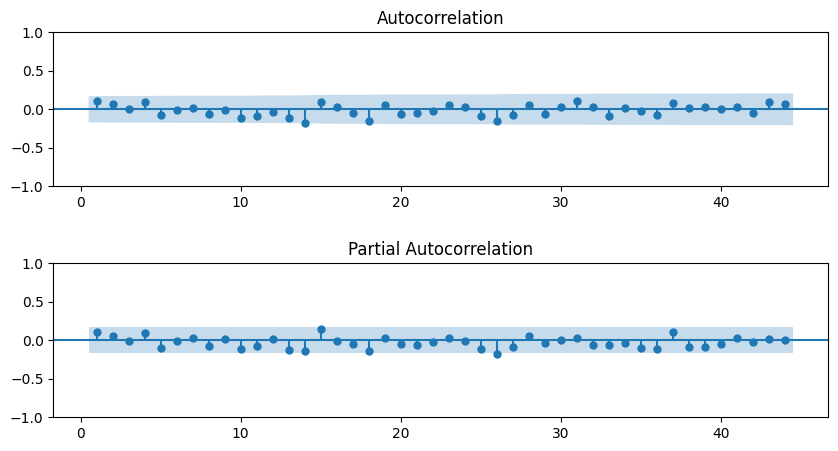


--- Bartlett's Test (Lag = 1) für z4 ---
Bartlett test statistic = -0.109
Bartlett test p-value = 0.211

--- Ljung-Box Q-Test (Lag = 11) für z4 ---
LBQ test statistic = 7.471
LBQ test p-value = 0.760


In [99]:
import qdatoolkit as qda

# Scores berechnen
scores = pca.transform(x_centered)
# Zuerst sicherstellen, dass wir 4 Spalten aus den berechneten Scores auswählen
# (z1, z2, z3, z4)
scores_df = pd.DataFrame(scores[:, :4], columns=['z1', 'z2', 'z3', 'z4'])
#  Faustregel für die Anzahl der Lags beim LBQ-Test: L < sqrt(n)
# Da du n = 132 Bilder hast, ist sqrt(132) ≈ 11.48. Wir wählen also lag = 11.
lag_test = 11

# Wir überprüfen die Unabhängigkeit für die ersten beiden Scores (z1 und z2)
col_names = ['z1', 'z2', "z3", "z4"]

for col_name in col_names:
    print(f"\n" + "="*50)
    print(f"ANALYSE FÜR HAUPTKOMPONENTE: {col_name}")
    print("="*50)
    
    # Die Zeitreihe der jeweiligen Hauptkomponente extrahieren
    series = scores_df[col_name]
    
    # 1. ACF- & PACF-Plots sowie Runs Test
    # Der Standardaufruf erstellt die Autokorrelations-Plots und führt den Runs-Test aus.
    print(f"\n--- Runs Test für {col_name} ---")
    _ = qda.Assumptions(series).independence()
    
    # 2. Bartlett's Test bei Lag 1
    # H0: Die wahre Autokorrelation bei Lag 1 ist gleich 0 (keine Autokorrelation)
    # H1: Die wahre Autokorrelation ist ungleich 0
    print(f"\n--- Bartlett's Test (Lag = 1) für {col_name} ---")
    _ = qda.Assumptions(series).independence(plotit=False, ac_test='bartlett', lag=10)
    
    # 3. Ljung-Box Q-Test (LBQ) für mehrere Lags
    # H0: Die Autokorrelationen der ersten L Lags sind alle 0
    # H1: Mindestens ein Lag weist eine signifikante Autokorrelation auf
    print(f"\n--- Ljung-Box Q-Test (Lag = {lag_test}) für {col_name} ---")
    _ = qda.Assumptions(series).independence(plotit=False, ac_test='lbq', lag=lag_test)

We see that k1, k2 and k4 are independant. k3 is not independant so we have to explain that:
- runs model and barlett test show no significance
- 132 is not all too much data
- no trend of lags before lag 10, no model of ARIMA fits
- lag 10 is late, very complicated model to fit
- probably a foto stacking problem or a slight periodic problem
- -> we see error but choose to call data indepeddant, lets see if we have a problem in the control charts

Now we have to check normality for the four ks.
we choose the qq charts for visualisations and the shapiro wil test


--- Normalitätsprüfung für z1 ---


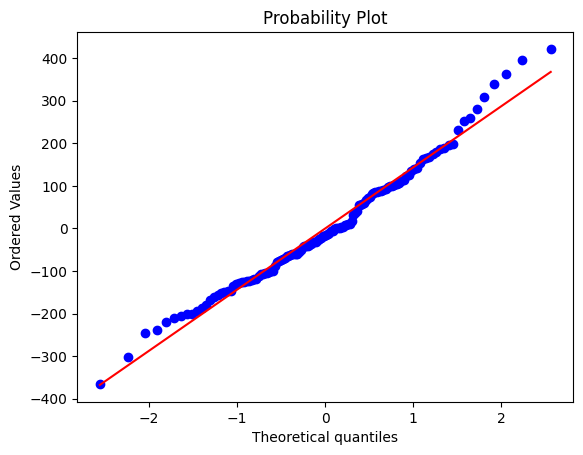

Shapiro-wilk test statistic = 0.983
Shapiro-wilk test p-value = 0.097

--- Normalitätsprüfung für z2 ---


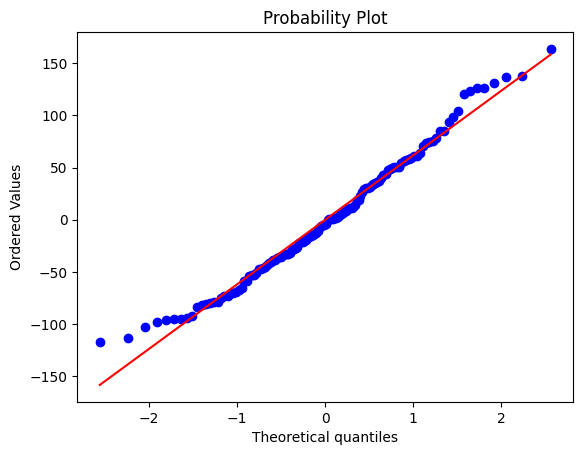

Shapiro-wilk test statistic = 0.981
Shapiro-wilk test p-value = 0.067

--- Normalitätsprüfung für z3 ---


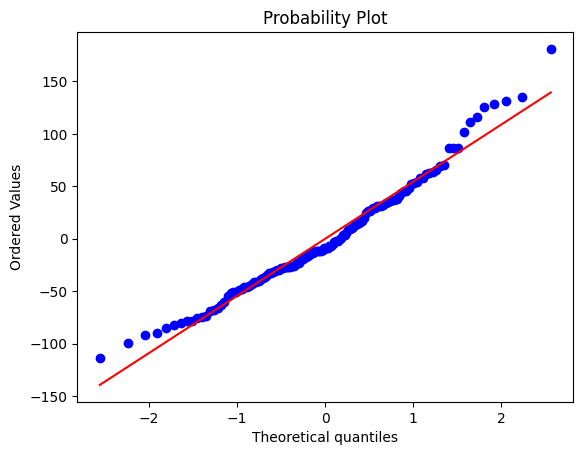

Shapiro-wilk test statistic = 0.974
Shapiro-wilk test p-value = 0.013

--- Normalitätsprüfung für z4 ---


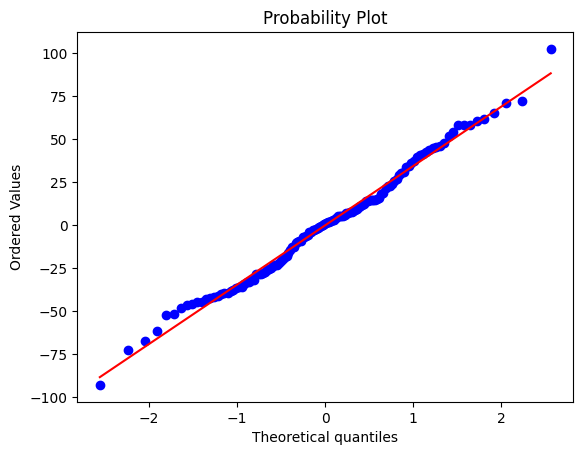

Shapiro-wilk test statistic = 0.992
Shapiro-wilk test p-value = 0.654


In [100]:
# Liste aller 4 Hauptkomponenten
col_names = ['z1', 'z2', 'z3', 'z4']

for col_name in col_names:
    print(f"\n--- Normalitätsprüfung für {col_name} ---")
    
    # Die Zeitreihe der jeweiligen Hauptkomponente extrahieren
    series = scores_df[col_name]
    
    # Führt den Shapiro-Wilk Test durch und plottet Q-Q Plot sowie Histogramm
    _ = qda.Assumptions(series).normality()

Wir sehen, dass der SW test bei k=3 zeigt, dass es nicht normal ist. Da unser controll chart normaverteilung voraussetzt, müssen wir die daten transformieren. dazu nehmen wir den box cox transformation. danach prüfen wir ob diese funktioniert hat oder nicht

Optimaler Lambda-Wert für z3 = 0.634

--- Normalitätsprüfung nach Box-Cox Transformation ---


c:\Users\deana\anaconda3\envs\QDA_environment_WIN\lib\site-packages\numpy\core\_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
c:\Users\deana\anaconda3\envs\QDA_environment_WIN\lib\site-packages\qdatoolkit\models.py:640: UserWarning: A numpy array was passed to the Assumptions class and converted to Pandas Series.
Note that all other methods in qda-toolkit only accept Pandas Series or Pandas Dataframe.
  warnings.warn(


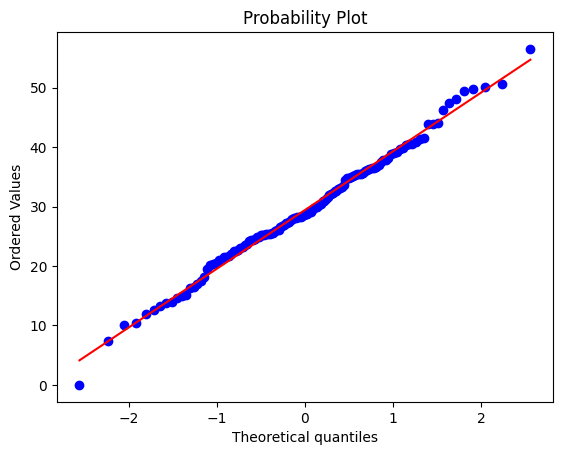

Shapiro-wilk test statistic = 0.995
Shapiro-wilk test p-value = 0.924


In [101]:
#Die Zeitreihe der dritten Hauptkomponente extrahieren
z3_series = scores_df['z3']

# Box-Cox erfordert strikt positive Daten. 
# Falls negative Werte vorhanden sind, verschieben wir die Serie ins Positive.
if z3_series.min() <= 0:
    shift_value = abs(z3_series.min()) + 1
    z3_series_positive = z3_series + shift_value
else:
    z3_series_positive = z3_series

# Box-Cox Transformation durchführen. 
# Die Funktion findet dabei automatisch den besten Lambda-Wert.
[z3_bc, lmbda] = stats.boxcox(z3_series_positive)

print('Optimaler Lambda-Wert für z3 = %.3f' % lmbda)

# Normalität der transformierten Daten direkt wieder überprüfen
print("\n--- Normalitätsprüfung nach Box-Cox Transformation ---")
_ = qda.Assumptions(z3_bc).normality()

k3 wurde problemlose normalisiert. dabei hat sich der mittelwert geändert. dieser muss wieder zentriert werden um mit den anderen k werten zusammen zu kommen. Um sicherzugehen dass z3 mit den anderen wieder zentriert ist, muss der mittelwert = 0 sein (oder wenigstens nache dran).

In [102]:
# 1. Mittelwert des transformierten Vektors berechnen
mean_z3_bc = np.mean(z3_bc)
print(f"Mittelwert von z3 bevor erneuter Zentrierung: {np.mean(mean_z3_bc):.4f}")

# 2. Den Vektor zentrieren, indem der Mittelwert von jedem Wert abgezogen wird
z3_bc_centered = z3_bc - mean_z3_bc

# Zur Kontrolle: Der neue Mittelwert sollte nun extrem nah an 0 (Null) liegen
print(f"Mittelwert von z3 nach erneuter Zentrierung: {np.mean(z3_bc_centered):.4f}")

# 3. Die alte z3-Komponente im Dataframe durch die transformierte 
# und zentrierte Version ersetzen. So passt z3 wieder perfekt zu z1, z2 und z4.
scores_df['z3'] = z3_bc_centered

Mittelwert von z3 bevor erneuter Zentrierung: 29.4196
Mittelwert von z3 nach erneuter Zentrierung: 0.0000


Da jetzt alles in ordnung ist möchte ich die control charts einführen.
Zuerst den T^2 chart:
Für jedes deiner 132 Bilder berechnest du den T2-Wert. Da wir Einzelbeobachtungen haben (n=1), lautet die Formel T2=(x−xˉ)′S−1(x−xˉ), wobei x dein Vektor aus den 4 Scores ist und S die Kovarianzmatrix

The UCL is calculated using the BETA distribution.


c:\Users\deana\anaconda3\envs\QDA_environment_WIN\lib\site-packages\pandas\core\indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


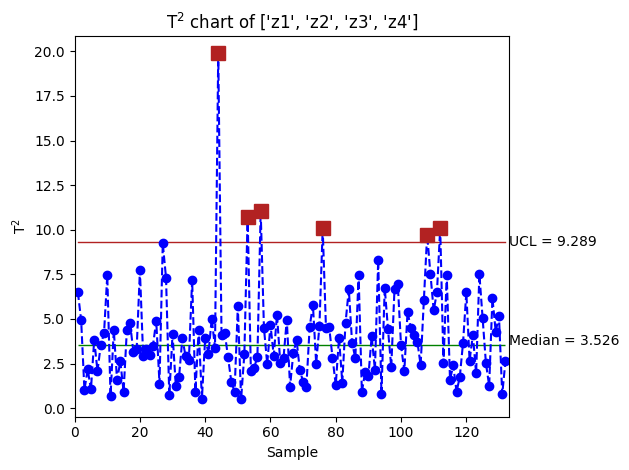

In [103]:
# Berechnet die T2 Hotelling Karte automatisch, nutzt bei Phase 1 (n=1) 
# die korrekten Limits und plottet das Chart.
# 1. Parameter definieren
m = 132       # Anzahl der Bilder (Beobachtungen)
p = 4         # Anzahl der Variablen (Hauptkomponenten z1, z2, z3, z4)
n = 1         # Einzelbeobachtungen
alpha = 0.05  # Signifikanzniveau (oder 0.01 / 0.0027, je nach deiner Wahl)

T2_qda = qda.ControlCharts.T2hotelling(scores_df, ['z1', 'z2', 'z3', 'z4'], sample_size=(m, n), alpha=alpha)

we see, that 6 points are OOC but that is expected because with alpha=0.05, 5% can be OOC. with 132 pictures we expect 132*0.05 OOC, which is 6.6.

because we are in space we dont want to waste the valuable time of the space engineer too much, so we have a warning limit at alpha 0.05 and they only go when there is an error with alpha=0.0027. 

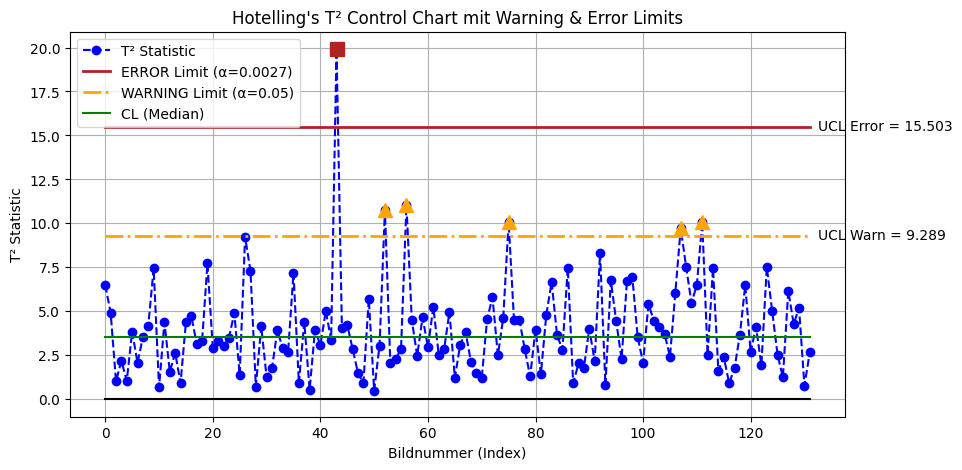

In [104]:
# 1. Parameter definieren
m = 132       # Anzahl der Bilder
p = 4         # Anzahl der Variablen
n = 1         # Einzelbeobachtungen

# Zwei verschiedene Signifikanzniveaus für Warning und Error definieren
alpha_warning = 0.05
alpha_error = 0.0027

# Die Scores auswählen, die wir überwachen wollen
scores_to_monitor = scores_df[['z1', 'z2', 'z3', 'z4']]

# Mittelwertvektor der 4 Scores berechnen 
Xbar = scores_to_monitor.mean()

# Kovarianzmatrix S berechnen und invertieren
# --- NEU (Short Range Estimator / Successive Differences für n=1) ---
# 1. Differenzen zwischen aufeinanderfolgenden Zeilen berechnen
diffs = scores_to_monitor.diff().dropna()

# 2. Matrix berechnen: (Transponierte Differenzen * Differenzen) / (2 * (m - 1))
S = (diffs.transpose().dot(diffs)) / (2 * (m - 1))

# 3. Invertieren
S_inv = np.linalg.inv(S)

# DataFrame für die T2-Statistiken vorbereiten
T2_df = pd.DataFrame(index=scores_to_monitor.index)
T2_df['T2'] = np.nan

# 2. Die Statistik: T2-Werte in einer Schleife berechnen
for i in range(m):
    x = scores_to_monitor.iloc[i]
    # Formel: T2 = (x - x_bar)' * S^-1 * (x - x_bar)
    T2_df['T2'].iloc[i] = n * (x - Xbar).transpose().dot(S_inv).dot(x - Xbar)

# 3. Das Kontrolllimit (UCL & LCL) mit der Beta-Verteilung berechnen
# Formel: UCL = m*(m-1)^2 / m * Beta(p/2, (m-p-1)/2)
beta_quantile = stats.beta.ppf(1 - alpha, p/2, (m-p-1)/2)
T2_df['T2_UCL'] = ((m-1)**2) / m * beta_quantile

# Die Center Line (CL) wird typischerweise auf den Median der T2-Werte gesetzt
T2_df['T2_CL'] = T2_df['T2'].median() 
T2_df['T2_LCL'] = 0

# Test auf Out-of-Control (OOC) Punkte (Werte über UCL markieren)
T2_df['T2_TEST'] = np.where((T2_df['T2'] > T2_df['T2_UCL']), T2_df['T2'], np.nan)

# 2. Zwei verschiedene Kontrolllimits (UCL) mit der Beta-Verteilung berechnen
beta_quantile_warning = stats.beta.ppf(1 - alpha_warning, p/2, (m-p-1)/2)
T2_df['UCL_WARNING'] = ((m-1)**2) / m * beta_quantile_warning

beta_quantile_error = stats.beta.ppf(1 - alpha_error, p/2, (m-p-1)/2)
T2_df['UCL_ERROR'] = ((m-1)**2) / m * beta_quantile_error

# Center Line (CL) und Lower Control Limit (LCL)
T2_df['T2_CL'] = T2_df['T2'].median() 
T2_df['T2_LCL'] = 0

# Werte über dem ERROR-Limit identifizieren
T2_df['TEST_ERROR'] = np.where((T2_df['T2'] > T2_df['UCL_ERROR']), T2_df['T2'], np.nan)
# Optional: Werte identifizieren, die nur das Warning-Limit überschreiten
T2_df['TEST_WARNING'] = np.where((T2_df['T2'] > T2_df['UCL_WARNING']) & (T2_df['T2'] <= T2_df['UCL_ERROR']), T2_df['T2'], np.nan)

# 3. Das Chart mit zwei Linien plotten
plt.figure(figsize=(10, 5))
plt.plot(T2_df['T2'], color='b', linestyle='--', marker='o', label='T² Statistic')

# Die beiden Linien für Warning und Error plotten
plt.plot(T2_df['UCL_ERROR'], color='firebrick', linewidth=2, label='ERROR Limit (α=0.0027)')
plt.plot(T2_df['UCL_WARNING'], color='orange', linestyle='-.', linewidth=2, label='WARNING Limit (α=0.05)')

plt.plot(T2_df['T2_CL'], color='g', label='CL (Median)')
plt.plot(T2_df['T2_LCL'], color='black')

plt.ylabel('T² Statistic')
plt.xlabel('Bildnummer (Index)')
plt.title("Hotelling's T² Control Chart mit Warning & Error Limits")

# Die OOC-Punkte markieren (Rot für Error, Orange für Warning)
plt.plot(T2_df['TEST_ERROR'], linestyle='none', marker='s', color='firebrick', markersize=10)
plt.plot(T2_df['TEST_WARNING'], linestyle='none', marker='^', color='orange', markersize=10)

# Limit-Werte an den rechten Rand schreiben (KORRIGIERT: .iloc[0] hinzugefügt)
plt.text(len(T2_df)+0.5, T2_df['UCL_ERROR'].iloc[0], f"UCL Error = {T2_df['UCL_ERROR'].iloc[0]:.3f}", verticalalignment='center')
plt.text(len(T2_df)+0.5, T2_df['UCL_WARNING'].iloc[0], f"UCL Warn = {T2_df['UCL_WARNING'].iloc[0]:.3f}", verticalalignment='center')

plt.legend(loc='upper left')
plt.grid(True)
plt.show()

now we also need a other chart to see what the T2 doesnt see.
we have 2 variants for that:
Methode 1: Univariate I-MR-Karten für die Hauptkomponenten dazu braucht man aber auch eine korrektur damit sich die wahrscheinliochekit für einen fehlarlarm nicht aufsummiert bei den 4 charts
Methode 2: SVM machine

Familienbezogenes Alpha (Gesamt): 0.05
Korrigiertes Alpha pro Karte:     0.01274
Berechneter K-Wert für I-MR:      2.491

--- I-MR Chart für Hauptkomponente z1 ---


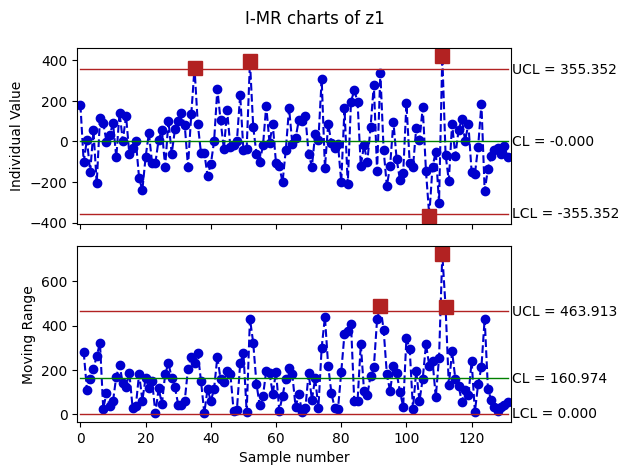

--- I-MR Chart für Hauptkomponente z2 ---


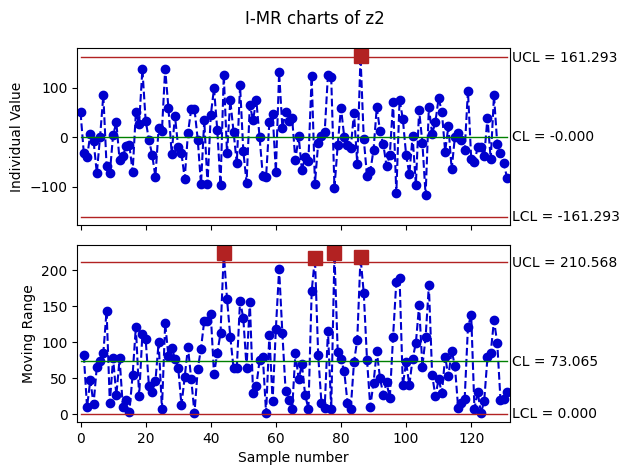

--- I-MR Chart für Hauptkomponente z3 ---


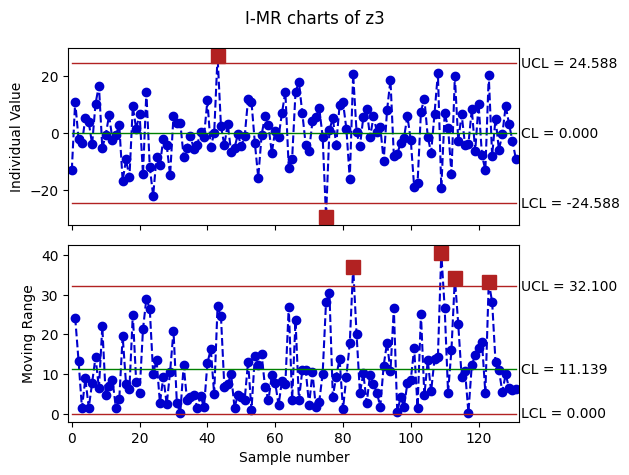

--- I-MR Chart für Hauptkomponente z4 ---


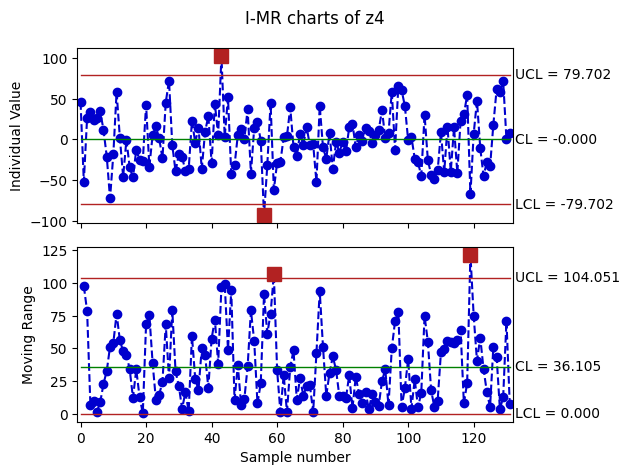

In [105]:
# 1. Parameter für die Šidák-Korrektur definieren
alpha_fam = 0.05  # Der gewünschte Gesamtfehler (Family-wise Type I error)
k = 4             # Anzahl der unabhängigen Hauptkomponenten (z1, z2, z3, z4)

# 2. Šidák-Korrektur anwenden: alpha_ind = 1 - (1 - alpha_fam)^(1/k)
alpha_ind = 1 - (1 - alpha_fam)**(1/k)

# 3. Den entsprechenden K-Wert (Z-Wert) für die I-MR Karten berechnen
K_alpha = stats.norm.ppf(1 - alpha_ind/2)

print(f"Familienbezogenes Alpha (Gesamt): {alpha_fam}")
print(f"Korrigiertes Alpha pro Karte:     {alpha_ind:.5f}")
print(f"Berechneter K-Wert für I-MR:      {K_alpha:.3f}\n")

# 4. I-MR Karten für jede der 4 Komponenten in einer Schleife erstellen
col_names = ['z1', 'z2', 'z3', 'z4']

for col in col_names:
    print(f"--- I-MR Chart für Hauptkomponente {col} ---")
    # Wir nutzen das qdatoolkit exakt wie in den Unterlagen
    _ = qda.ControlCharts.IMR(scores_df, col, K=K_alpha)

um die error und warnsache hinzuzufügen muss folgendes passieren:

K-Wert für Warning: 1.960
K-Wert für Error:   3.000


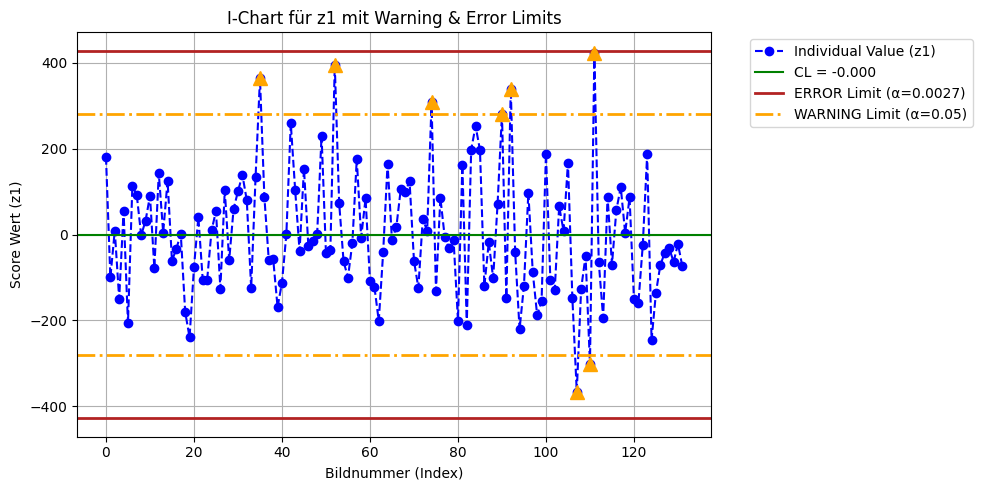

In [106]:
# Wir wählen hier beispielhaft die erste Hauptkomponente z1
series = scores_df['z1']

# 1. Moving Range (MR) und Mittelwerte berechnen
MR = series.diff().abs()
MR_mean = MR.mean()
I_mean = series.mean()

# d2 Konstante für n=2 abrufen (da der Moving Range immer aus 2 Werten gebildet wird)
d2 = qda.constants.getd2(2)

# 2. Alpha-Werte definieren und die dazugehörigen K-Werte (Z-Quantile) berechnen
alpha_warning = 0.05
alpha_error = 0.0027

# K-Wert Berechnung: K = z_(1 - alpha/2) für beidseitige Limits
K_warn = stats.norm.ppf(1 - alpha_warning/2)
K_error = stats.norm.ppf(1 - alpha_error/2) 

print(f"K-Wert für Warning: {K_warn:.3f}")
print(f"K-Wert für Error:   {K_error:.3f}")

# 3. Control Limits für die Individual-Karte (I-Chart) berechnen
# Formel: CL = mean, UCL/LCL = mean +/- K * (MR_mean / d2)
CL = I_mean

UCL_warn = I_mean + K_warn * (MR_mean / d2)
LCL_warn = I_mean - K_warn * (MR_mean / d2)

UCL_error = I_mean + K_error * (MR_mean / d2)
LCL_error = I_mean - K_error * (MR_mean / d2)

# Out-of-Control Punkte identifizieren
test_error = np.where((series > UCL_error) | (series < LCL_error), series, np.nan)
test_warning = np.where(((series > UCL_warn) & (series <= UCL_error)) | ((series < LCL_warn) & (series >= LCL_error)), series, np.nan)

# 4. Das Chart visualisieren
plt.figure(figsize=(10, 5))

# Datenpunkte plotten
plt.plot(series, color='b', linestyle='--', marker='o', label='Individual Value (z1)')

# Center Line
plt.axhline(CL, color='g', label=f'CL = {CL:.3f}')

# ERROR Limits (Rot)
plt.axhline(UCL_error, color='firebrick', linewidth=2, label=f'ERROR Limit (α={alpha_error})')
plt.axhline(LCL_error, color='firebrick', linewidth=2)

# WARNING Limits (Orange, gestrichelt)
plt.axhline(UCL_warn, color='orange', linestyle='-.', linewidth=2, label=f'WARNING Limit (α={alpha_warning})')
plt.axhline(LCL_warn, color='orange', linestyle='-.', linewidth=2)

# Auffällige Punkte markieren
plt.plot(test_error, linestyle='none', marker='s', color='firebrick', markersize=10)
plt.plot(test_warning, linestyle='none', marker='^', color='orange', markersize=10)

plt.title('I-Chart für z1 mit Warning & Error Limits')
plt.xlabel('Bildnummer (Index)')
plt.ylabel('Score Wert (z1)')

# Legende außerhalb des Plots platzieren für bessere Übersicht
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Erwartete Fehler: ~6.6 Punkte
Tatsächliche OOC-Punkte: 6 (4.5 %)


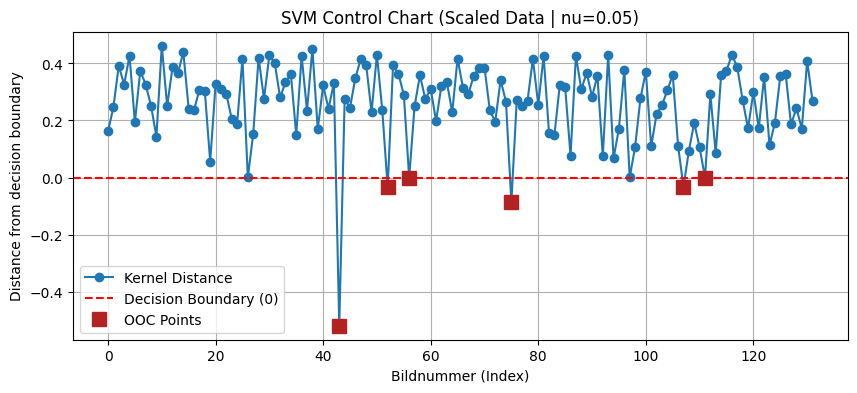

In [107]:
from sklearn import svm
from sklearn.preprocessing import StandardScaler

# 1. Daten standardisieren (Zwingend notwendig für RBF-SVM!)
scaler = StandardScaler()
# Wir skalieren die 4 Scores, damit alle Komponenten gleich stark gewichtet werden
x_scaled = scaler.fit_transform(scores_df[['z1', 'z2', 'z3', 'z4']])

# 1. 1-Class SVM Modell erstellen 
# 'nu' entspricht in etwa deinem Alpha
# 'gamma' definiert, wie eng sich die Grenze an die Daten schmiegt
alpha_svm = 0.05
model = svm.OneClassSVM(kernel='rbf', gamma=0.01, nu=alpha_svm)

# 3. Modell an die SKALIERTEN Daten fitten
model.fit(x_scaled)

# 4. Die Kernel-Distanz berechnen (wieder mit skalierten Daten!)
scores_df['boundary_dist'] = model.decision_function(x_scaled)

# Werte unter 0 (außerhalb der Grenze) als Out-of-Control (OOC) markieren
scores_df['SVM_TEST'] = np.where(scores_df['boundary_dist'] < 0, scores_df['boundary_dist'], np.nan)

# Kurz ausgeben, wie viele Fehler wir wirklich haben:
n_errors = scores_df['SVM_TEST'].count()
print(f"Erwartete Fehler: ~{m * alpha_svm:.1f} Punkte")
print(f"Tatsächliche OOC-Punkte: {n_errors} ({(n_errors/m)*100:.1f} %)")

# 5. Kernel-Distanz-Chart plotten
plt.figure(figsize=(10, 4))
plt.plot(scores_df['boundary_dist'], 'o-', label='Kernel Distance')
plt.axhline(y=0, color='r', linestyle='--', label='Decision Boundary (0)')
plt.plot(scores_df['SVM_TEST'], linestyle='none', marker='s', color='firebrick', markersize=10, label='OOC Points')

plt.title(f"SVM Control Chart (Scaled Data | nu={alpha_svm})")
plt.xlabel('Bildnummer (Index)')
plt.ylabel('Distance from decision boundary')
plt.legend()
plt.grid(True)
plt.show()

i had to put the gamma way down to fight overfitting. 132 pictures probably arent enough to reliably use this method.

another method ist the SPE chart out of reference "profile monitoring and probability density"

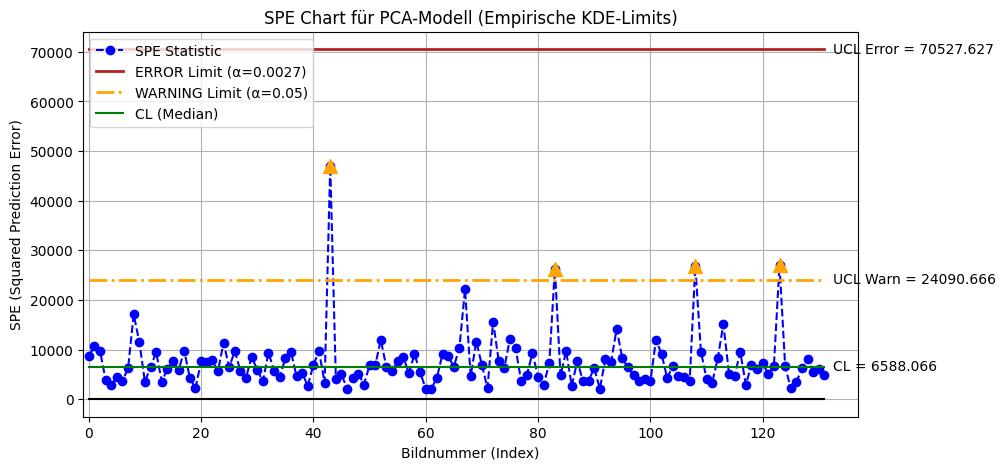

In [108]:
from scipy.integrate import cumulative_trapezoid

# 1. Die Statistik: Deine Originaldaten mit den 4 Hauptkomponenten rekonstruieren
k = 4
x_reconstructed_centered = scores_df[['z1', 'z2', 'z3', 'z4']].dot(pca.components_[0:k, :])

# Vorhersagefehler (Rauschen) berechnen
Error = x_centered - x_reconstructed_centered

# SPE-Wert für jedes deiner 132 Bilder berechnen (Summe der quadrierten Abweichungen)
spe_values = np.sum(Error**2, axis=1)

# DataFrame für das SPE-Chart vorbereiten
SPE_df = pd.DataFrame(spe_values, columns=['SPE'])

# 2. Kontrollgrenzen empirisch über KDE schätzen (Methode aus ESE10)
alpha_warning = 0.05
alpha_error = 0.0027

# KDE auf die berechneten SPE-Werte anwenden, um die Verteilung zu glätten [1]
kde_spe = stats.gaussian_kde(SPE_df['SPE'])

# Ein feines Grid für die SPE-Werte erstellen (von 0 bis etwas über das Maximum) [1]
spe_range = np.linspace(0, np.max(SPE_df['SPE']) * 1.5, 1000)

# Kumulierte Dichtefunktion (CDF) aus der KDE berechnen [2]
cdf_spe = cumulative_trapezoid(kde_spe.evaluate(spe_range), spe_range, initial=0)

# Quantile (UCL, CL) aus der empirischen Verteilung interpolieren [3]
# Da das SPE-Chart einseitig ist (wir suchen nur nach zu großen Fehlern), nutzen wir 1 - alpha
UCL_ERROR = np.interp(1 - alpha_error, cdf_spe, spe_range)
UCL_WARNING = np.interp(1 - alpha_warning, cdf_spe, spe_range)
CL_SPE = np.interp(0.5, cdf_spe, spe_range) # Median als Center Line [3]

# Limits im Dataframe speichern
SPE_df['UCL_ERROR'] = UCL_ERROR
SPE_df['UCL_WARNING'] = UCL_WARNING
SPE_df['CL'] = CL_SPE
SPE_df['LCL'] = 0

# Out-of-Control (OOC) Punkte markieren
SPE_df['TEST_ERROR'] = np.where((SPE_df['SPE'] > SPE_df['UCL_ERROR']), SPE_df['SPE'], np.nan)
SPE_df['TEST_WARNING'] = np.where((SPE_df['SPE'] > SPE_df['UCL_WARNING']) & (SPE_df['SPE'] <= SPE_df['UCL_ERROR']), SPE_df['SPE'], np.nan)
# SPE Chart plotten
plt.figure(figsize=(10, 5))
plt.plot(SPE_df['SPE'], color='b', linestyle='--', marker='o', label='SPE Statistic')

# Die beiden empirischen Linien für Warning und Error plotten
plt.plot(SPE_df['UCL_ERROR'], color='firebrick', linewidth=2, label=f'ERROR Limit (α={alpha_error})')
plt.plot(SPE_df['UCL_WARNING'], color='orange', linestyle='-.', linewidth=2, label=f'WARNING Limit (α={alpha_warning})')

plt.plot(SPE_df['CL'], color='g', label='CL (Median)')
plt.plot(SPE_df['LCL'], color='black')

plt.ylabel('SPE (Squared Prediction Error)')
plt.xlabel('Bildnummer (Index)')
plt.title("SPE Chart für PCA-Modell (Empirische KDE-Limits)")

# OOC Punkte markieren
plt.plot(SPE_df['TEST_ERROR'], linestyle='none', marker='s', color='firebrick', markersize=10)
plt.plot(SPE_df['TEST_WARNING'], linestyle='none', marker='^', color='orange', markersize=10)

# Limit-Werte an den rechten Rand schreiben [4]
plt.text(len(SPE_df)+0.5, UCL_ERROR, f"UCL Error = {UCL_ERROR:.3f}", verticalalignment='center')
plt.text(len(SPE_df)+0.5, UCL_WARNING, f"UCL Warn = {UCL_WARNING:.3f}", verticalalignment='center')
plt.text(len(SPE_df)+0.5, CL_SPE, f"CL = {CL_SPE:.3f}", verticalalignment='center')

plt.legend(loc='upper left')
plt.grid(True)
plt.xlim(-1, len(SPE_df) + 5)
plt.show()

# Results

- Den Scree-Plot zeigen, der die Wahl des K (Anzahl der Komponenten) rechtfertigt.
- Den T2-Chart und den SPE-Chart für die 132 Trainingsbilder plotten.
- Prüfung: Gibt es Punkte, die in Phase 1 das Kontrolllimit überschreiten? Falls ja, musst du diskutieren, ob das Falschalarme sind oder ob du diese Ausreißer entfernst und das PCA-Modell neu trainierst (klassischer SPC-Schritt)

# References (if any)

Alle genutzten Paper (z.B. "A Review and Perspective on Control Charting with Image Data") und Vorlesungsfolien auflisten.

# PHASE 2 -----------------------------

# Preliminary data analysis

- Neue Bilderserie laden und ein paar Beispiele (insbesondere defekte Schichten) visualisieren.
- Wieder in 1D-Vektoren umwandeln und mit dem Durchschnittsbild aus Phase 1 zentrieren

# Test of your proposed approach on new data

- Sehr wichtig: Das PCA-Modell darf für Phase 2 nicht neu trainiert werden! Du wendest exakt das in Phase 1 berechnete Modell auf die neuen Daten an.
- Die Scores und Residuen für die neuen Bilder berechnen.
- Die Phase-2-Kontrollkarten für T2 und SPE erstellen. Beachte, dass in Phase 2 theoretisch andere Kontrollgrenzen (oft basierend auf der F-Verteilung statt Beta) zur Anwendung kommen als in Phase 1.

# Discussion

- Gegenüberstellung: Abgleich deiner erkannten Alarme in den T2- und SPE-Charts mit dem "Ground Truth"-Vektor (also der Lösung, wann wirklich ein Defekt vorlag).
- Kritische Bewertung der Performance: Wie gut war die Balance? Wurden die Defekte (True Positives) schnell genug erkannt? Gab es zu viele Falschalarme (False Positives)?.
- Einschätzung der Methode: Wo liegen die Schwächen der PCA bei dieser konkreten Anwendung? (z.B. reagiert sie vielleicht sensibel auf leicht verschobenes Prozessleuchten)